In [1]:
import XRootD
import copy # copiar variables
import os   # gestionar rutas
import uproot   # Leer archivos ROOT sin usar ROOT directamente.
import awkward as ak  # Manejar arreglos tipo "jagged" (listas de listas, una por evento).
import vector   # vectores de Lorentz
vector.register_awkward()
import matplotlib.pyplot as plt # Para hacer gráficos.
import matplotlib.image as mpimg
import tqdm # barras de progreso
import re
import random
import subprocess
import atlasopenmagic as atom # Paquete de datos abiertos ATLAS
from tabulate import tabulate # Para hacer tablas
from matplotlib.ticker import FixedLocator, FixedFormatter

import glob
import gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

## Estoy usando los datos de: 

## https://opendata.cern.ch/record/80036

## los cuales almacené en:

In [2]:
ArchivosIones = sorted(glob.glob("parquets_final/*.parquet"))

for f in ArchivosIones:
    print(f, pq.ParquetFile(f).metadata.num_rows)

parquets_final/tracks_RAA_bloque_001.parquet 7454243
parquets_final/tracks_RAA_bloque_002.parquet 7424326
parquets_final/tracks_RAA_bloque_003.parquet 108254472
parquets_final/tracks_RAA_bloque_004.parquet 107312805
parquets_final/tracks_RAA_bloque_005.parquet 104798372
parquets_final/tracks_RAA_bloque_006.parquet 104236559
parquets_final/tracks_RAA_bloque_007.parquet 110085190
parquets_final/tracks_RAA_bloque_008.parquet 111440053
parquets_final/tracks_RAA_bloque_009.parquet 115012088
parquets_final/tracks_RAA_bloque_010.parquet 112476052
parquets_final/tracks_RAA_bloque_011.parquet 115103087


##

In [3]:
print(pq.ParquetFile(ArchivosIones[0]).schema.names)

['runNumber', 'eventNumber', 'CentralityMin', 'CentralityMax', 'qOverP', 'theta', 'phi', 'eta']


## Quiero saber con cuántos eventos en total estoy trabajando

In [4]:
particulas_totales = 0
eventos_totales = set()

for f in ArchivosIones:
    df = pd.read_parquet(f, columns=["runNumber", "eventNumber"])

    # contar muones
    particulas_totales += len(df)

    # contar eventos únicos
    eventos_totales.update(zip(df["runNumber"], df["eventNumber"]))

# resultado final
print("\n=========================")
print("PARTÍCULAS TOTALES:", particulas_totales)
print("EVENTOS TOTALES:", len(eventos_totales))


PARTÍCULAS TOTALES: 1003597247
EVENTOS TOTALES: 1102243


# Centralidad promedio por evento

In [5]:
df = pd.read_parquet(f, columns=[
    "runNumber",
    "eventNumber",
    "CentralityMin",
    "CentralityMax"
])

df["centrality_prom"] = 0.5 * (
    df["CentralityMin"] + df["CentralityMax"]
)

# Cantidad de eventos segun la centralidad de la colisión

In [6]:
bins = [0, 5, 10] + list(range(20, 110, 10))
labels = ["0-5%", "5-10%"] + [f"{i}-{i+10}%" for i in range(10, 100, 10)]

# acumuladores
Npart_total = pd.Series(0, index=labels, dtype=np.int64)
Nevt_total  = pd.Series(0, index=labels, dtype=np.int64)

# para no contar dos veces el mismo evento
eventos_vistos = set()

for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=1_000_000,
        columns=["runNumber", "eventNumber", "CentralityMin", "CentralityMax"]
    ):
        df = batch.to_pandas()

        # centralidad promedio
        df["centrality_prom"] = 0.5 * (
            df["CentralityMin"] + df["CentralityMax"]
        )

        # =========================
        # PARTÍCULAS
        # =========================
        cent_part = df["centrality_prom"]
        cent_part = cent_part[np.isfinite(cent_part)]

        clases_part = pd.cut(
            cent_part,
            bins=bins,
            labels=labels,
            right=False
        )

        Npart = clases_part.value_counts().sort_index()
        Npart_total = Npart_total.add(Npart, fill_value=0).astype(np.int64)

        # =========================
        # EVENTOS
        # =========================
        eventos_batch = df[[
            "runNumber",
            "eventNumber",
            "centrality_prom"
        ]].drop_duplicates()

        for _, row in eventos_batch.iterrows():
            clave = (int(row["runNumber"]), int(row["eventNumber"]))

            if clave not in eventos_vistos:
                eventos_vistos.add(clave)

                c = row["centrality_prom"]

                if np.isfinite(c):
                    for i in range(len(labels)):
                        if bins[i] <= c < bins[i + 1]:
                            Nevt_total.iloc[i] += 1
                            break

        del df, cent_part, clases_part, Npart, eventos_batch
        gc.collect()

# =========================
# TABLA FINAL
# =========================
total_evt  = int(Nevt_total.sum())
total_part = int(Npart_total.sum())

tabla_evt = pd.DataFrame({
    "Clase de centralidad": labels,
    "N_evt": Nevt_total.values,
    "N_part": Npart_total.values,
})

tabla_evt["Porcentaje"] = 100 * tabla_evt["N_evt"] / total_evt

tabla_evt.loc[len(tabla_evt)] = [
    "Total",
    total_evt,
    total_part,
    100.0
]

display(
    tabla_evt.style
    .format({
        "N_evt": "{:,}",
        "N_part": "{:,}",
        "Porcentaje": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption("Distribución de eventos y partículas por centralidad")
)

# diccionarios útiles
Nevt_dict  = dict(zip(labels, Nevt_total.values))
Npart_dict = dict(zip(labels, Npart_total.values))

Clase de centralidad,N_evt,N_part,Porcentaje
0-5%,"46,757","220,343,794",4.24
5-10%,"47,302","167,282,539",4.29
10-20%,"95,476","237,809,936",8.66
20-30%,"93,956","151,898,154",8.52
30-40%,"94,357","97,728,078",8.56
40-50%,"95,358","65,248,880",8.65
50-60%,"94,296","33,643,175",8.55
60-70%,"94,555","17,293,087",8.58
70-80%,"94,468","7,863,929",8.57
80-90%,0,0,0.00


# Momento transverso

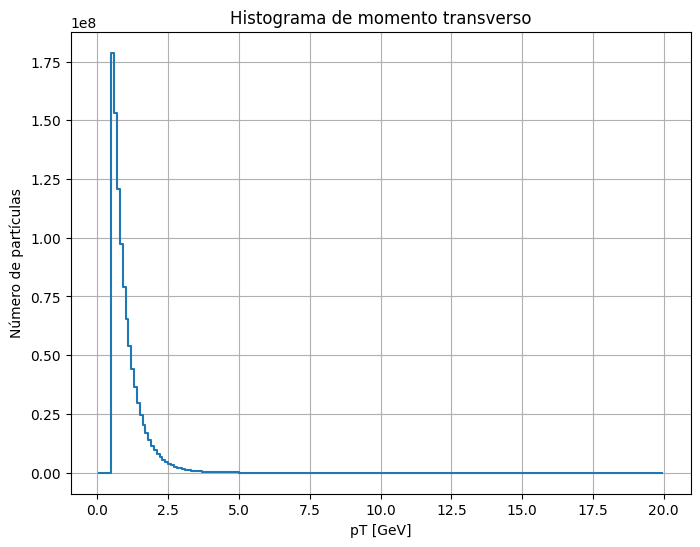

In [7]:
bins = np.arange(0, 20.1, 0.1)
hist_total = np.zeros(len(bins) - 1)

for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["qOverP", "theta"]
    ):
        df = batch.to_pandas()

        pt = np.where(
            df["qOverP"] != 0,
            (1.0 / np.abs(df["qOverP"])) * np.sin(df["theta"]) / 1000.0,
            np.nan
        )

        counts, _ = np.histogram(pt[np.isfinite(pt)], bins=bins)
        hist_total += counts

        del df, pt, counts
        gc.collect()

centros = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(8, 6))
plt.step(centros, hist_total, where="mid")
plt.xlabel("pT [GeV]")
plt.ylabel("Número de partículas")
plt.title("Histograma de momento transverso")
plt.grid()
plt.show()

# Histograma de Seudorapidez

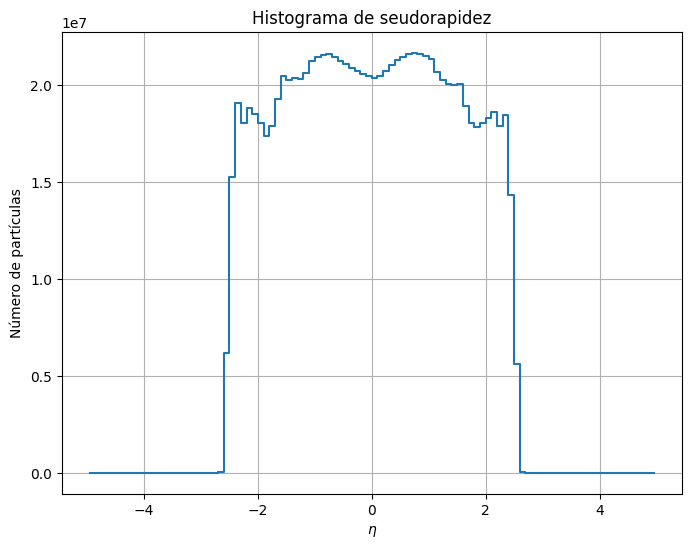

In [8]:
bins = np.arange(-5, 5.1, 0.1)
hist_total = np.zeros(len(bins) - 1)

for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["eta"]
    ):
        df = batch.to_pandas()

        eta = df["eta"].to_numpy()
        counts, _ = np.histogram(eta[np.isfinite(eta)], bins=bins)
        hist_total += counts

        del df, eta, counts
        gc.collect()

centros = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(8, 6))
plt.step(centros, hist_total, where="mid")
plt.xlabel(r"$\eta$")
plt.ylabel("Número de partículas")
plt.title("Histograma de seudorapidez")
plt.grid()
plt.show()

# Espectro de partículas por evento
## Promedio de partículas cargadas por evento por unidad de seudorapidez y momento transverso

# $$
\frac{1}{N_{evt}}\frac{d^{2}N_{PbPb}}{d\eta\, dp_{T}}
= \frac{1}{N_{evt}}\,E\,\frac{d^{3}N_{PbPb}}{d^{3}p}
$$
# Obs: Ya hice la demostración de la ecuación anterior.

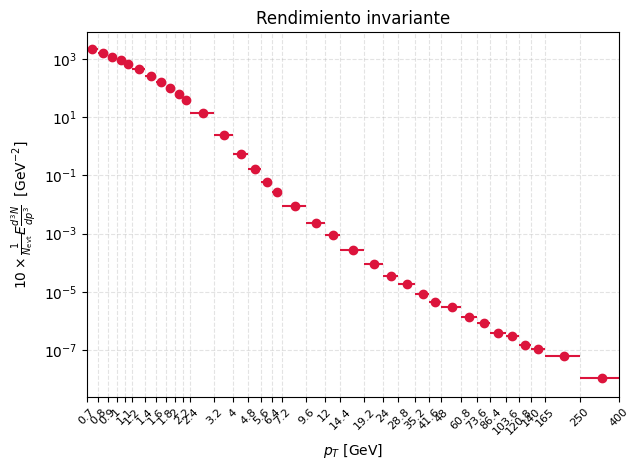

Nevt en 0-5% = 46757

Tabla: Rendimiento invariante


pT_low [GeV],pT_high [GeV],pT_center [GeV],10*(1/Nevt)*E*d^3N/dp^3 [GeV^-2],stat_err [GeV^-2],counts
0.7,0.8,0.750,2243.6035032550,0.7135331780,"9,886,985"
0.8,0.9,0.850,1598.8483382113,0.5658038794,"7,985,143"
0.9,1.0,0.950,1175.9071969561,0.4589828627,"6,563,767"
1.0,1.1,1.050,899.3155419848,0.3817975602,"5,548,274"
1.1,1.2,1.150,676.7692078033,0.3164777074,"4,572,934"
1.2,1.4,1.300,455.2825670248,0.1726337027,"6,955,220"
1.4,1.6,1.500,267.1465376648,0.1231078924,"4,708,985"
1.6,1.8,1.700,161.3917389136,0.0898820441,"3,224,161"
1.8,2.0,1.900,99.0932256163,0.0666195866,"2,212,504"
2.0,2.2,2.100,61.7237869889,0.0500119036,"1,523,205"


In [9]:
# =========================
# 0) Definir clase de centralidad y factor del rendimiento invariante
# =========================
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10

# =========================
# 1) Bins de pT EXACTOS hasta 400 GeV
# =========================
pt_intervalos = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 3.2, 4.0,
    4.8, 5.6, 6.4, 7.2, 9.6, 12.0, 14.4, 19.2, 24.0, 28.8, 35.2, 41.6,
    48.0, 60.8, 73.6, 86.4, 103.6, 120.8, 140.0, 165.0, 250.0, 400.0
], dtype=float)

pt_low        = pt_intervalos[:-1]
pt_high       = pt_intervalos[1:]
Delta_pt      = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

# acumulador del histograma
N_ij = np.zeros(len(pt_intervalos) - 1, dtype=np.int64)

# conjunto para eventos únicos
eventos_vistos = set()

# =========================
# 2) Leer parquets iterativamente
# =========================
for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["runNumber", "eventNumber", "CentralityMin", "CentralityMax", "qOverP", "theta"]
    ):
        df = batch.to_pandas()

        # centralidad promedio por fila (repetida por track)
        centrality_prom = 0.5 * (df["CentralityMin"] + df["CentralityMax"])

        # =========================
        # 3) Contar eventos únicos en la clase de centralidad
        # =========================
        mask_evt = (
            np.isfinite(centrality_prom)
            & (centrality_prom >= CENT_LO)
            & (centrality_prom < CENT_HI)
        )

        eventos_batch = df.loc[mask_evt, ["runNumber", "eventNumber"]].drop_duplicates()

        for row in eventos_batch.itertuples(index=False):
            eventos_vistos.add((int(row.runNumber), int(row.eventNumber)))

        # =========================
        # 4) pT (GeV) y pseudorrapidez η por partícula; corte |η|<1
        # =========================
        qOverP = df["qOverP"].to_numpy()
        theta  = df["theta"].to_numpy()

        p_mev = np.where(qOverP != 0, 1.0 / np.abs(qOverP), np.nan)
        pt_gev = (p_mev * np.sin(theta)) / 1000.0
        eta = -np.log(np.tan(theta / 2.0))

        mask_part = (
            mask_evt.to_numpy()
            & np.isfinite(qOverP)
            & np.isfinite(theta)
            & np.isfinite(pt_gev)
            & np.isfinite(eta)
            & (np.abs(eta) < 1.0)
        )

        pt_Filtrado = pt_gev[mask_part]

        # histograma acumulado
        counts, _ = np.histogram(pt_Filtrado, bins=pt_intervalos)
        N_ij += counts

        del df, centrality_prom, eventos_batch, qOverP, theta, p_mev, pt_gev, eta, pt_Filtrado, counts
        gc.collect()

# número total de eventos en la clase
Nevt = len(eventos_vistos)

# =========================
# 5) (1/Nevt) d^2N/(dη dpT) con |η|<1 → Δη = 2
# =========================
Delta_eta = 2.0
Espectro = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# =========================
# 6) Rendimiento invariante
# =========================
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr   = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# =========================
# 7) Gráfica SOLO de rendimiento invariante
# =========================
mask_bins = N_ij > 0
x    = pt_centro_Bin[mask_bins]
y2   = InvYield[mask_bins]
e2   = InvErr[mask_bins]
xerr = np.vstack([x - pt_low[mask_bins], pt_high[mask_bins] - x])

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.8))

ax.errorbar(
    x, y2, xerr=xerr, yerr=e2,
    fmt="o", linestyle="none", capsize=0, color="crimson"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(pt_intervalos[0], pt_intervalos[-1])
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(
    rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]"
)
ax.set_title(r"Rendimiento invariante")
ax.grid(True, which="both", ls="--", alpha=0.35)

ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# =========================
# 8) Tabla SOLO de rendimiento invariante
# =========================
mask = N_ij > 0
tabla_invar = pd.DataFrame({
    "pT_low [GeV]": pt_low[mask],
    "pT_high [GeV]": pt_high[mask],
    "pT_center [GeV]": pt_centro_Bin[mask],
    f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]": InvYield[mask],
    "stat_err [GeV^-2]": InvErr[mask],
    "counts": N_ij[mask],
})

col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"
tabla_invar[col_y] = tabla_invar[col_y].map(lambda v: float(f"{v:.10f}"))
tabla_invar["stat_err [GeV^-2]"] = tabla_invar["stat_err [GeV^-2]"].map(lambda v: float(f"{v:.10f}"))

print(f"Nevt en {CENT_LO}-{CENT_HI}% = {Nevt}")
print("\nTabla: Rendimiento invariante")

display(
    tabla_invar.style
    .format({
        "pT_low [GeV]": "{:.1f}",
        "pT_high [GeV]": "{:.1f}",
        "pT_center [GeV]": "{:.3f}",
        col_y: "{:.10f}",
        "stat_err [GeV^-2]": "{:.10f}",
        "counts": "{:,}"
    })
    .hide(axis="index")
    .set_caption("Tabla de rendimiento invariante")
)

### En el siguiente enlace, se muestra el resultado (gráfico) de lo que debería obtener:

### https://www.hepdata.net/record/ins1496050?version=2&table=Table%208


Tabla: Comparación ATLAS vs HEPData para centralidad 0-5%  (archivo: /home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV/HEPData-ins1496050-v2-Table_1.csv)


PTlow [GeV],PThigh [GeV],PT [GeV],Valor medido ATLAS,Valor medido HEP,Porcentaje de error [%],counts
0.7,0.8,0.75,2243.603503254999850,2382.230000000000018,5.819190,"9,886,985"
0.8,0.9,0.85,1598.848338211299961,1798.220000000000027,11.087167,"7,985,143"
0.9,1.0,0.95,1175.907196956100051,1339.400000000000091,12.206421,"6,563,767"
1.0,1.1,1.05,899.315541984800007,1027.660000000000082,12.489000,"5,548,274"
1.1,1.2,1.15,676.769207803299992,763.706999999999994,11.383658,"4,572,934"
1.2,1.4,1.30,455.282567024800016,529.852999999999952,14.073797,"6,955,220"
1.4,1.6,1.50,267.146537664800007,309.115999999999985,13.577253,"4,708,985"
1.6,1.8,1.70,161.391738913599994,194.688999999999993,17.102795,"3,224,161"
1.8,2.0,1.90,99.093225616300003,117.241000000000000,15.479034,"2,212,504"
2.0,2.2,2.10,61.723786988900002,75.129199999999997,17.843146,"1,523,205"


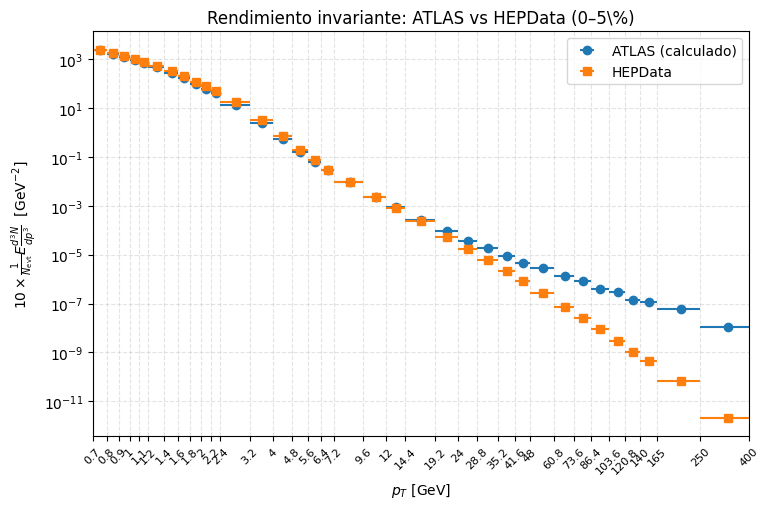

In [10]:
 # =========================
# Comparación ATLAS (calculado desde parquets) vs HEPData
# Requiere que YA existan:
# tabla_invar, FACTOR_INV, CENT_LO, CENT_HI, pt_intervalos
# =========================

HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"

hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_1.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_2.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_3.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_4.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_5.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_6.csv",
}

# =========================
# 1) Elegir archivo HEPData según centralidad
# =========================
clave_cent = (CENT_LO, CENT_HI)

if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}"
    )

archivo_hep = os.path.join(HEP_DIR, hep_archivos_por_centralidad[clave_cent])

if not os.path.exists(archivo_hep):
    raise FileNotFoundError(
        f"No existe: {archivo_hep}\n"
        f"Tip: revisa nombres con: !ls -lh {HEP_DIR}"
    )

# =========================
# 2) Leer HEPData
# =========================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
y_hep_raw   = df_hep.iloc[:, 3].astype(float).to_numpy()

factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    m = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*\*", nombre_col_valor)
    if m:
        factor_hep = float(m.group(1))
except Exception:
    factor_hep = 1.0

y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_value": y_hep,
})

# =========================
# 3) Tabla ATLAS (desde tabla_invar)
# =========================
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"

tabla_atlas = (
    tabla_invar[[
        "pT_low [GeV]",
        "pT_high [GeV]",
        "pT_center [GeV]",
        col_y,
        "counts"
    ]]
    .copy()
    .rename(columns={col_y: "Valor medido ATLAS"})
)

# =========================
# 4) Merge robusto por bordes de bin
# =========================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_value"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["Valor medido ATLAS"] - tabla_comp["HEP_value"]) / tabla_comp["HEP_value"]
) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "HEP_value": "Valor medido HEP",
    "counts": "counts",
})

# =========================
# 5) Reordenar columnas dejando counts al final
# =========================
tabla_comp = tabla_comp[[
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "Valor medido ATLAS",
    "Valor medido HEP",
    "Porcentaje de error [%]",
    "counts"
]]

# =========================
# 6) Mostrar tabla profesional
# =========================
print(
    f"\nTabla: Comparación ATLAS vs HEPData para centralidad "
    f"{CENT_LO}-{CENT_HI}%  (archivo: {archivo_hep})"
)

display(
    tabla_comp.style
    .format({
        "PTlow [GeV]": "{:.1f}",
        "PThigh [GeV]": "{:.1f}",
        "PT [GeV]": "{:.2f}",
        "Valor medido ATLAS": "{:.15f}",
        "Valor medido HEP": "{:.15f}",
        "Porcentaje de error [%]": "{:.6f}",
        "counts": "{:,}",
    })
    .hide(axis="index")
    .set_caption(
        f"Comparación del rendimiento invariante: ATLAS calculado desde parquets vs HEPData ({CENT_LO}-{CENT_HI}%)"
    )
)

# =========================
# 7) Gráfico superpuesto: ATLAS vs HEPData
# =========================
x      = tabla_comp["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_comp["Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp["Valor medido HEP"].to_numpy(dtype=float)

ptlow  = tabla_comp["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_comp["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = (
    np.isfinite(x)
    & np.isfinite(y_at)
    & np.isfinite(y_hep2)
    & (x > 0)
    & (y_at > 0)
    & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))

ax.errorbar(
    x[m], y_at[m],
    xerr=xerr[:, m],
    fmt="o",
    linestyle="none",
    capsize=0,
    label="ATLAS (calculado)"
)

ax.errorbar(
    x[m], y_hep2[m],
    xerr=xerr[:, m],
    fmt="s",
    linestyle="none",
    capsize=0,
    label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(
    rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]"
)
ax.set_title(
    rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%)"
)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))
plt.tight_layout()
plt.show()

### Observación: Obtuve una muy buena aproximación de los valores numéricos.

# Recortando el intervalo


Tabla: Comparación ATLAS vs HEPData para centralidad 0-5% (archivo: /home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV/HEPData-ins1496050-v2-Table_1.csv) con recorte pT<= 19.2 GeV


PTlow [GeV],PThigh [GeV],PT [GeV],Valor medido ATLAS,Valor medido HEP,Porcentaje de error [%],counts
0.7,0.8,0.75,2243.603503254999850,2382.230000000000018,5.819190,"9,886,985"
0.8,0.9,0.85,1598.848338211299961,1798.220000000000027,11.087167,"7,985,143"
0.9,1.0,0.95,1175.907196956100051,1339.400000000000091,12.206421,"6,563,767"
1.0,1.1,1.05,899.315541984800007,1027.660000000000082,12.489000,"5,548,274"
1.1,1.2,1.15,676.769207803299992,763.706999999999994,11.383658,"4,572,934"
1.2,1.4,1.30,455.282567024800016,529.852999999999952,14.073797,"6,955,220"
1.4,1.6,1.50,267.146537664800007,309.115999999999985,13.577253,"4,708,985"
1.6,1.8,1.70,161.391738913599994,194.688999999999993,17.102795,"3,224,161"
1.8,2.0,1.90,99.093225616300003,117.241000000000000,15.479034,"2,212,504"
2.0,2.2,2.10,61.723786988900002,75.129199999999997,17.843146,"1,523,205"


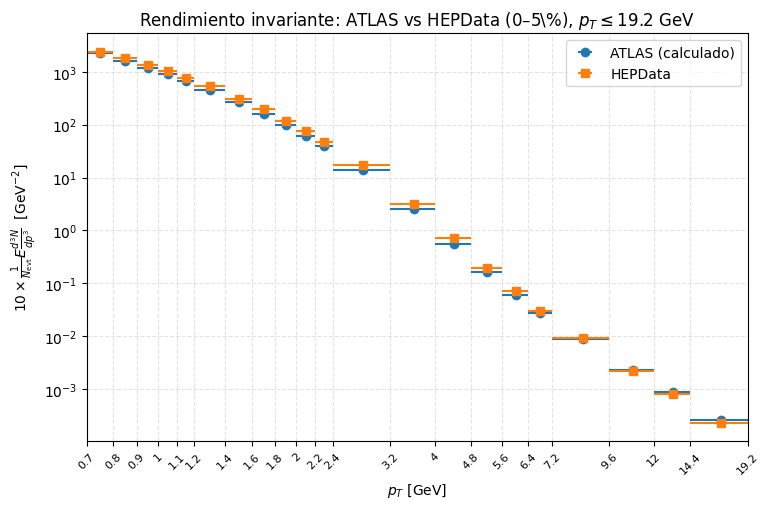

In [12]:
# =========================
# (DESPUÉS de tu tabla_invar) Comparación ATLAS (calculado desde parquets)
# vs HEPData + GRÁFICO SUPERPUESTO (RECORTE pT<=19.2) + ruta HEP_DIR
# Requiere que YA existan:
# tabla_invar, FACTOR_INV, CENT_LO, CENT_HI, pt_intervalos
# =========================

PT_MAX = 19.2  # recorte máximo en pT [GeV]

HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_1.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_2.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_3.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_4.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_5.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_6.csv",
}

# =========================
# 1) Elegir archivo HEPData según centralidad
# =========================
clave_cent = (CENT_LO, CENT_HI)

if clave_cent not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No tengo mapeado el archivo HEPData para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones válidas: {sorted(list(hep_archivos_por_centralidad.keys()))}"
    )

archivo_hep = os.path.join(HEP_DIR, hep_archivos_por_centralidad[clave_cent])

if not os.path.exists(archivo_hep):
    raise FileNotFoundError(
        f"No existe: {archivo_hep}\n"
        f"Tip: revisa nombres con: !ls -lh {HEP_DIR}"
    )

# =========================
# 2) Leer HEPData
# =========================
df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")

pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
y_hep_raw   = df_hep.iloc[:, 3].astype(float).to_numpy()

factor_hep = 1.0
try:
    nombre_col_valor = str(df_hep.columns[3])
    m = re.match(r"^\s*([0-9]+(?:\.[0-9]+)?)\s*\*", nombre_col_valor)
    if m:
        factor_hep = float(m.group(1))
except Exception:
    factor_hep = 1.0

y_hep = y_hep_raw * (FACTOR_INV / factor_hep)

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_value": y_hep,
})

# =========================
# 3) Tabla ATLAS (desde tabla_invar, que viene de los parquets)
# =========================
col_y = f"{FACTOR_INV}*(1/Nevt)*E*d^3N/dp^3 [GeV^-2]"

tabla_atlas = (
    tabla_invar[[
        "pT_low [GeV]",
        "pT_high [GeV]",
        "pT_center [GeV]",
        col_y,
        "counts"
    ]]
    .copy()
    .rename(columns={col_y: "Valor medido ATLAS"})
)

# =========================
# 4) Merge robusto por bordes de bin
# =========================
for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_value"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

# =========================
# 5) Recorte en pT: conservar bins con borde superior <= PT_MAX
# =========================
tabla_comp = tabla_comp[tabla_comp["pT_high [GeV]"] <= PT_MAX].copy()

# =========================
# 6) Calcular porcentaje de error y renombrar columnas
# =========================
tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["Valor medido ATLAS"] - tabla_comp["HEP_value"]) /
    tabla_comp["HEP_value"]
) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "HEP_value": "Valor medido HEP",
})

# dejar counts como última columna
tabla_comp = tabla_comp[[
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "Valor medido ATLAS",
    "Valor medido HEP",
    "Porcentaje de error [%]",
    "counts"
]]

# =========================
# 7) Mostrar tabla profesional
# =========================
print(
    f"\nTabla: Comparación ATLAS vs HEPData para centralidad "
    f"{CENT_LO}-{CENT_HI}% (archivo: {archivo_hep}) con recorte pT<= {PT_MAX} GeV"
)

display(
    tabla_comp.style
    .format({
        "PTlow [GeV]": "{:.1f}",
        "PThigh [GeV]": "{:.1f}",
        "PT [GeV]": "{:.2f}",
        "Valor medido ATLAS": "{:.15f}",
        "Valor medido HEP": "{:.15f}",
        "Porcentaje de error [%]": "{:.6f}",
        "counts": "{:,}",
    })
    .hide(axis="index")
    .set_caption(
        f"Comparación del rendimiento invariante: ATLAS calculado desde parquets vs HEPData ({CENT_LO}-{CENT_HI}%), con recorte pT ≤ {PT_MAX} GeV"
    )
)

# =========================
# 8) Gráfico superpuesto: ATLAS vs HEPData
# =========================
x      = tabla_comp["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_comp["Valor medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_comp["Valor medido HEP"].to_numpy(dtype=float)

ptlow  = tabla_comp["PTlow [GeV]"].to_numpy(dtype=float)
pthigh = tabla_comp["PThigh [GeV]"].to_numpy(dtype=float)
xerr   = np.vstack([x - ptlow, pthigh - x])

m = (
    np.isfinite(x)
    & np.isfinite(y_at)
    & np.isfinite(y_hep2)
    & (x > 0)
    & (y_at > 0)
    & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))

ax.errorbar(
    x[m], y_at[m],
    xerr=xerr[:, m],
    fmt="o",
    linestyle="none",
    capsize=0,
    label="ATLAS (calculado)"
)

ax.errorbar(
    x[m], y_hep2[m],
    xerr=xerr[:, m],
    fmt="s",
    linestyle="none",
    capsize=0,
    label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(float(np.min(ptlow)) if len(ptlow) else 0.7, PT_MAX)
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(
    rf"${FACTOR_INV}\times\frac{{1}}{{N_{{\rm evt}}}}E\frac{{d^3N}}{{dp^3}}$  [$\mathrm{{GeV}}^{{-2}}$]"
)
ax.set_title(
    rf"Rendimiento invariante: ATLAS vs HEPData ({CENT_LO:.0f}–{CENT_HI:.0f}\%), $p_T\leq{PT_MAX}$ GeV"
)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

if "pt_intervalos" in globals():
    ticks = pt_intervalos[pt_intervalos <= PT_MAX]
else:
    ticks = np.unique(np.concatenate([ptlow, pthigh]))
    ticks = ticks[ticks <= PT_MAX]

ticks = np.sort(ticks)

ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# Espectro diferencial de la sección eficaz inelástica en colisiones protón-protón

### Tomé los datos de HEP (Tabla 7)

Directorio actual: /home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA
Buscando archivo: /home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV/HEPData-Table_7-Espectro-pp.csv

Tabla: Espectro pp (HEPData Table 7)


,pT_low [GeV],pT_high [GeV],pT_center [GeV],(1/N) E d^3N/dp^3 [GeV^-2]
0,0.5,0.6,0.55,9.756980e-01
1,0.6,0.7,0.65,6.396480e-01
2,0.7,0.8,0.75,4.193870e-01
3,0.8,0.9,0.85,2.969680e-01
4,0.9,1.0,0.95,2.039110e-01
5,1.0,1.1,1.05,1.472850e-01
6,1.1,1.2,1.15,1.067570e-01
7,1.2,1.4,1.30,6.983660e-02
8,1.4,1.6,1.50,3.930150e-02
9,1.6,1.8,1.70,2.388490e-02


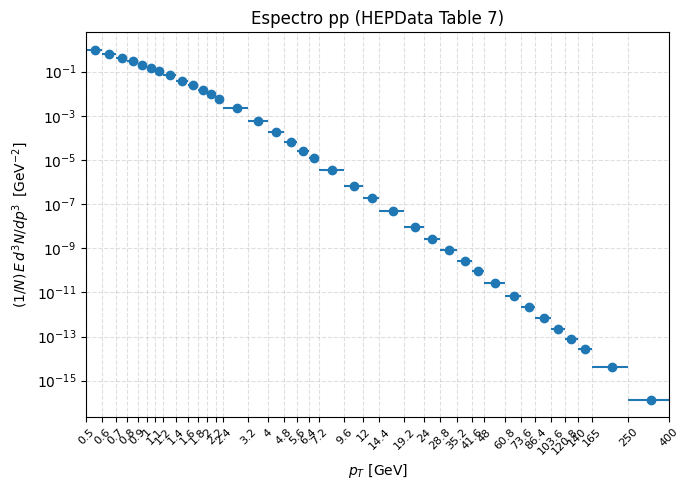

In [13]:
# =========================
# 0) Ruta correcta del CSV (AJUSTA SOLO ESTA PARTE)
# =========================
HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
archivo = os.path.join(HEP_DIR, "HEPData-Table_7-Espectro-pp.csv")

print("Directorio actual:", os.getcwd())
print("Buscando archivo:", archivo)
if not os.path.exists(archivo):
    raise FileNotFoundError(f"No existe el archivo:\n{archivo}\nRevisa el nombre exacto con: !ls -lh {HEP_DIR}")

# =========================
# 1) Leer CSV ignorando el header con "#"
# =========================
df = pd.read_csv(archivo, comment="#", sep=",", engine="python")

# =========================
# 2) Tomar columnas (LOW/HIGH) para pT y el espectro
# =========================
pt_low  = df.iloc[:, 1].astype(float).to_numpy()   # PT [GeV] LOW
pt_high = df.iloc[:, 2].astype(float).to_numpy()   # PT [GeV] HIGH

pt   = 0.5 * (pt_low + pt_high)                    # centro del bin
xerr = np.vstack([pt - pt_low, pt_high - pt])      # barras horizontales

y = df.iloc[:, 3].astype(float).to_numpy()         # (1/N) E d^3N/dp^3 [GeV^-2]

# =========================
# 2.5) Tabla
# =========================
tabla_pp = pd.DataFrame({
    "pT_low [GeV]": pt_low,
    "pT_high [GeV]": pt_high,
    "pT_center [GeV]": pt,
    "(1/N) E d^3N/dp^3 [GeV^-2]": y,
})
print("\nTabla: Espectro pp (HEPData Table 7)")
display(tabla_pp)

# =========================
# 3) Gráfico
# =========================
plt.figure(figsize=(7, 5))
plt.errorbar(pt, y, xerr=xerr, fmt="o", linestyle="none", capsize=0)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$(1/N)\,E\,d^3N/dp^3\ \,[\mathrm{GeV}^{-2}]$")
plt.title("Espectro pp (HEPData Table 7)")
plt.grid(True, which="both", ls="--", alpha=0.4)

ticks = np.unique(np.concatenate([pt_low, pt_high]))
ticks = np.sort(ticks)

ax = plt.gca()
ax.set_xlim(ticks.min(), ticks.max())
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# Factor de modificación nuclear/Función de soplamiento nuclear promedio (TAA)

### La información la puedo encontrar en: 

#### La información la puedo encontrar en: 

- Punto uno ATLAS-CONF-2017-012: Mean values of
https://cds.cern.ch/record/2244824/files/ATLAS-CONF-2017-012.pdf  
CERN Document Server

- Punto dos CMS Charged-particle nuclear modification factors at 5.02 TeV — contiene RAA y la incertidumbre de TAA que se usa en el análisis:
 📄 https://arxiv.org/pdf/1611.01664.pdf

- Punto tres ATLAS y ALICE measurements de espectros y RAA en Pb-Pb 5.02 TeV — muestran resultados de RAA,implica el uso de TAA del Glauber model:
 📄 https://cds.cern.ch/record/2842355/files/ANA-HION-2018-17-PAPER.pdf

- Punto cuatro https://doi.org/10.1016/j.physletb.2018.10.076
  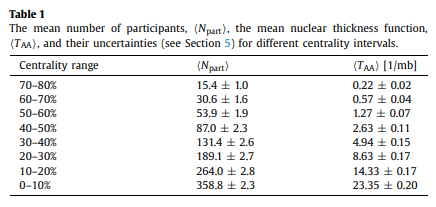

# FACTOR DE MODIFICACIÓN NUCLEAR (RAA)

TAA asignado automáticamente para 5-10%: 20.47 mb^-1


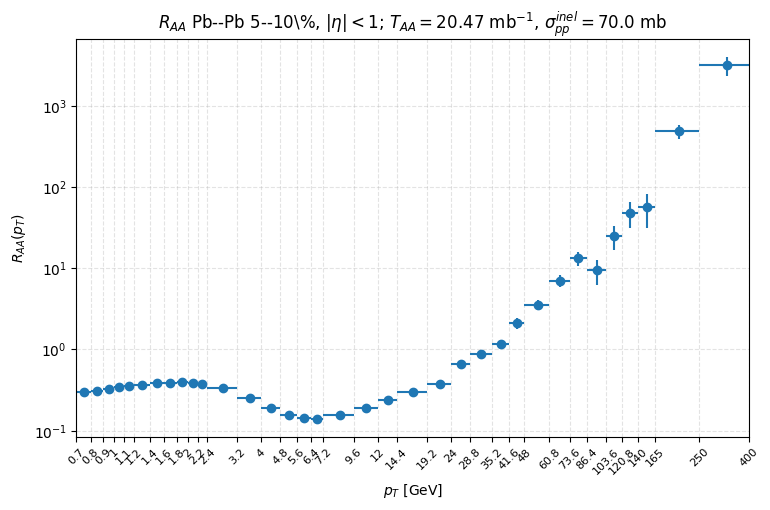


Nevt (PbPb 5-10%) = 47,302 | bins válidos = 35/35

Tabla: RAA (solo bins válidos)


PT_low [GeV],PThigh [GeV],PT_center [GeV],RAA,RAA_stat_err,counts
0.7,0.8,0.75,0.302015,0.000107,"8,091,136"
0.8,0.9,0.85,0.306257,0.000120,"6,584,446"
0.9,1.0,0.95,0.328998,0.000142,"5,428,285"
1.0,1.1,1.05,0.345823,0.000163,"4,555,199"
1.1,1.2,1.15,0.359445,0.000186,"3,758,654"
1.2,1.4,1.30,0.370426,0.000156,"5,728,798"
1.4,1.6,1.50,0.388306,0.000198,"3,899,504"
1.6,1.8,1.70,0.387023,0.000238,"2,676,974"
1.8,2.0,1.90,0.392960,0.000292,"1,839,584"
2.0,2.2,2.10,0.382655,0.000342,"1,269,831"


In [15]:
# =========================
# R_AA usando PbPb desde parquets + pp desde HEPData CSV con ruta
# =========================

# 0) Centralidad y factores
CENT_LO, CENT_HI = 5, 10
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0, 5): 26.23,
    (5, 10): 20.47,
    (10, 30): 11.7,
    (30, 50): 3.82,
    (50, 70): 0.934,
    (70, 90): 0.152
}

clave_cent = (int(CENT_LO), int(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(
        f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(TAA_por_centralidad.keys())}"
    )

TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# 1) Bins pT
pt_intervalos = np.array([
    0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 3.2, 4.0,
    4.8, 5.6, 6.4, 7.2, 9.6, 12.0, 14.4, 19.2, 24.0, 28.8, 35.2, 41.6,
    48.0, 60.8, 73.6, 86.4, 103.6, 120.8, 140.0, 165.0, 250.0, 400.0
], dtype=float)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

# acumuladores PbPb
N_ij = np.zeros(len(pt_intervalos) - 1, dtype=np.int64)
eventos_vistos = set()

# 2) Leer parquets iterativamente
for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["runNumber", "eventNumber", "CentralityMin", "CentralityMax", "qOverP", "theta"]
    ):
        df = batch.to_pandas()

        # centralidad promedio por fila
        centrality_prom = 0.5 * (df["CentralityMin"] + df["CentralityMax"])

        # 2a) filtrar eventos por centralidad
        mask_evt = (
            np.isfinite(centrality_prom)
            & (centrality_prom >= CENT_LO)
            & (centrality_prom < CENT_HI)
        )

        eventos_batch = df.loc[mask_evt, ["runNumber", "eventNumber"]].drop_duplicates()

        for row in eventos_batch.itertuples(index=False):
            eventos_vistos.add((int(row.runNumber), int(row.eventNumber)))

        # 2b) pT (GeV) y η; corte |η|<1
        qOverP = df["qOverP"].to_numpy()
        theta = df["theta"].to_numpy()

        p_mev = np.where(qOverP != 0, 1.0 / np.abs(qOverP), np.nan)
        pt_gev = (p_mev * np.sin(theta)) / 1000.0
        eta = -np.log(np.tan(theta / 2.0))

        mask_part = (
            mask_evt.to_numpy()
            & np.isfinite(qOverP)
            & np.isfinite(theta)
            & np.isfinite(pt_gev)
            & np.isfinite(eta)
            & (np.abs(eta) < 1.0)
        )

        pt_filtrado = pt_gev[mask_part]

        counts, _ = np.histogram(pt_filtrado, bins=pt_intervalos)
        N_ij += counts

        del df, centrality_prom, eventos_batch, qOverP, theta, p_mev, pt_gev, eta, pt_filtrado, counts
        gc.collect()

Nevt = len(eventos_vistos)
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# 3) (1/Nevt) d^2N/(dη dpT), Δη=2
Delta_eta = 2.0
Espectro = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# 4) Rendimiento invariante PbPb
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# 5) Leer pp (HEPData) desde ruta y escalar con el mismo FACTOR_INV
HEP_DIR = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
archivo_pp = os.path.join(HEP_DIR, "HEPData-Table_7-Espectro-pp.csv")

if not os.path.exists(archivo_pp):
    raise FileNotFoundError(
        f"No existe el archivo:\n{archivo_pp}\n"
        f"Revisa el nombre exacto con: !ls -lh {HEP_DIR}"
    )

df_pp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")

pt_low_pp  = df_pp.iloc[:, 1].astype(float).to_numpy()
pt_high_pp = df_pp.iloc[:, 2].astype(float).to_numpy()
pt_pp      = 0.5 * (pt_low_pp + pt_high_pp)
y_pp_raw   = df_pp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if df_pp.shape[1] >= 5:
    try:
        yerr_pp_raw = df_pp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

# 6) Interpolar pp a los centros de bin de PbPb en log-log
mask_ok = (
    (pt_pp > 0)
    & np.isfinite(pt_pp)
    & (y_pp > 0)
    & np.isfinite(y_pp)
)

pt_ok = pt_pp[mask_ok]
y_ok = y_pp[mask_ok]

logpt = np.log(pt_ok)
logy = np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (
    (pt_eval >= pt_ok.min())
    & (pt_eval <= pt_ok.max())
    & np.isfinite(pt_eval)
    & (pt_eval > 0)
)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(
    np.interp(np.log(pt_eval[mask_range]), logpt, logy)
)

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# 7) Calcular R_AA y su error
denom = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom

RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask = (
    (N_ij > 0)
    & np.isfinite(RAA)
    & np.isfinite(RAA_err)
    & np.isfinite(denom)
    & (denom > 0)
    & np.isfinite(InvYield)
    & (InvYield > 0)
)

# 8) Gráfico R_AA
x = pt_centro_Bin[mask]
xerr = np.vstack([x - pt_low[mask], pt_high[mask] - x])

fig, ax = plt.subplots(1, 1, figsize=(7.8, 5.2))
ax.errorbar(x, RAA[mask], xerr=xerr, yerr=RAA_err[mask], fmt="o", linestyle="none", capsize=0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(pt_intervalos[0], pt_intervalos[-1])
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(
    rf"$R_{{AA}}$ Pb--Pb {CENT_LO}--{CENT_HI}\%, $|\eta|<1$; "
    rf"$T_{{AA}}={TAA}$ mb$^{{-1}}$, $\sigma_{{pp}}^{{inel}}={SIGMA_PP_INEL}$ mb"
)
ax.grid(True, which="both", ls="--", alpha=0.35)

ticks = pt_intervalos
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()

plt.tight_layout()
plt.show()

# 9) Tabla R_AA
tabla_raa = pd.DataFrame({
    "PT_low [GeV]": pt_low[mask],
    "PThigh [GeV]": pt_high[mask],
    "PT_center [GeV]": pt_centro_Bin[mask],
    "RAA": RAA[mask],
    "RAA_stat_err": RAA_err[mask],
    "counts": N_ij[mask]
})

# dejar counts al final
tabla_raa = tabla_raa[[
    "PT_low [GeV]",
    "PThigh [GeV]",
    "PT_center [GeV]",
    "RAA",
    "RAA_stat_err",
    "counts"
]]

print(f"\nNevt (PbPb {CENT_LO}-{CENT_HI}%) = {Nevt:,} | bins válidos = {int(np.sum(mask))}/{len(pt_centro_Bin)}")
print("\nTabla: RAA (solo bins válidos)")

display(
    tabla_raa.style
    .format({
        "PT_low [GeV]": "{:.1f}",
        "PThigh [GeV]": "{:.1f}",
        "PT_center [GeV]": "{:.2f}",
        "RAA": "{:.6f}",
        "RAA_stat_err": "{:.6f}",
        "counts": "{:,}"
    })
    .hide(axis="index")
    .set_caption(
        f"Tabla de $R_{{AA}}$ para Pb--Pb {CENT_LO}-{CENT_HI}% usando parquets y referencia pp de HEPData"
    )
)

# Comparando resultados

TAA asignado automáticamente para 0-5%: 26.23 mb^-1

Tabla: Comparación R_AA ATLAS vs HEPData para centralidad 0-5% (archivo: HEPData-ins1496050-v2-Table_8.csv)


PTlow [GeV],PThigh [GeV],PT [GeV],RAA medido ATLAS,RAA medido HEP,Cuentas (ATLAS),Porcentaje de error [%]
0.7,0.8,0.75,0.291363,0.312275,9886985,6.697
0.8,0.9,0.85,0.293225,0.332891,7985143,11.916
0.9,1.0,0.95,0.314077,0.361109,6563767,13.024
1.0,1.1,1.05,0.332550,0.383584,5548274,13.304
1.1,1.2,1.15,0.345261,0.393276,4572934,12.209
1.2,1.4,1.30,0.355060,0.417100,6955220,14.874
1.4,1.6,1.50,0.370207,0.432394,4708985,14.382
1.6,1.8,1.70,0.368012,0.448111,3224161,17.875
1.8,2.0,1.90,0.373134,0.445619,2212504,16.266
2.0,2.2,2.10,0.362387,0.445238,1523205,18.608


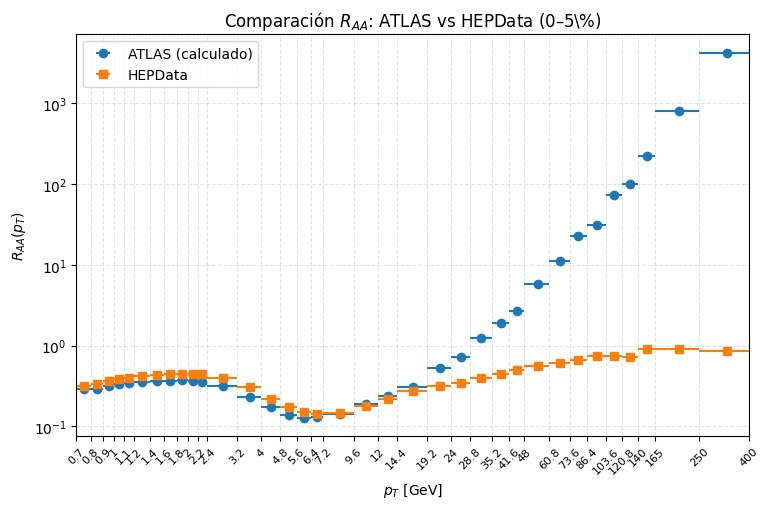

In [16]:
# =========================
# COMPARACIÓN R_AA: (ATLAS calculado desde parquets) vs HEPData + GRÁFICO SUPERPUESTO
# + agrega columna de CUENTAS (ATLAS) y fila final: TOTAL CUENTAS
# + mantiene PT mostrado con 2 decimales
# =========================

# -------------------------
# 0) Centralidad y factores
# -------------------------
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0.0, 5.0): 26.23,
    (5.0, 10.0): 20.47,
    (10.0, 30.0): 11.7,
    (30.0, 50.0): 3.82,
    (50.0, 70.0): 0.934,
    (70.0, 100.0): 0.152,
}

clave_cent = (float(CENT_LO), float(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(
        f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(TAA_por_centralidad.keys())}"
    )

TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# -------------------------
# 1) Bins pT
# -------------------------
pt_intervalos = np.array(
    [0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,
     24.0,28.8,35.2,41.6,48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0],
    dtype=float
)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

# -------------------------
# 2) PbPb desde parquets: eventos únicos + histograma pT
# -------------------------
N_ij = np.zeros(len(pt_intervalos) - 1, dtype=np.int64)
eventos_vistos = set()

for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["runNumber", "eventNumber", "CentralityMin", "CentralityMax", "qOverP", "theta"]
    ):
        df = batch.to_pandas()

        centrality_prom = 0.5 * (df["CentralityMin"] + df["CentralityMax"])

        mask_evt = (
            np.isfinite(centrality_prom)
            & (centrality_prom >= CENT_LO)
            & (centrality_prom < CENT_HI)
        )

        eventos_batch = df.loc[mask_evt, ["runNumber", "eventNumber"]].drop_duplicates()
        for row in eventos_batch.itertuples(index=False):
            eventos_vistos.add((int(row.runNumber), int(row.eventNumber)))

        qOverP = df["qOverP"].to_numpy()
        theta  = df["theta"].to_numpy()

        p_mev = np.where(qOverP != 0, 1.0 / np.abs(qOverP), np.nan)
        pt_gev = (p_mev * np.sin(theta)) / 1000.0
        eta = -np.log(np.tan(theta / 2.0))

        mask_part = (
            mask_evt.to_numpy()
            & np.isfinite(qOverP)
            & np.isfinite(theta)
            & np.isfinite(pt_gev)
            & np.isfinite(eta)
            & (np.abs(eta) < 1.0)
        )

        pt_filtrado = pt_gev[mask_part]
        counts, _ = np.histogram(pt_filtrado, bins=pt_intervalos)
        N_ij += counts

        del df, centrality_prom, eventos_batch, qOverP, theta, p_mev, pt_gev, eta, pt_filtrado, counts
        gc.collect()

Nevt = len(eventos_vistos)
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# -------------------------
# 3) Espectro (1/Nevt) d^2N/(deta dpT), Δη=2
# -------------------------
Delta_eta = 2.0
Espectro = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# -------------------------
# 4) Rendimiento invariante PbPb
# -------------------------
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# -------------------------
# 5) pp desde HEPData Table_7
# -------------------------
HEP_DIR_PP = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
archivo_pp = os.path.join(HEP_DIR_PP, "HEPData-Table_7-Espectro-pp.csv")

if not os.path.exists(archivo_pp):
    raise FileNotFoundError(
        f"No existe el archivo:\n{archivo_pp}\n"
        f"Revisa el nombre exacto con: !ls -lh {HEP_DIR_PP}"
    )

dfpp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")

pt_pp = 0.5 * (
    dfpp.iloc[:, 1].astype(float).to_numpy()
    + dfpp.iloc[:, 2].astype(float).to_numpy()
)
y_pp_raw = dfpp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if dfpp.shape[1] >= 5:
    try:
        yerr_pp_raw = dfpp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (
    (pt_eval >= pt_ok.min())
    & (pt_eval <= pt_ok.max())
    & np.isfinite(pt_eval)
    & (pt_eval > 0)
)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(
    np.interp(np.log(pt_eval[mask_range]), logpt, logy)
)

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# -------------------------
# 6) R_AA calculado + error
# -------------------------
denom = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask = (
    (N_ij > 0)
    & np.isfinite(RAA)
    & np.isfinite(RAA_err)
    & np.isfinite(denom)
    & (denom > 0)
    & (InvYield > 0)
)

# -------------------------
# 7) Leer R_AA de HEPData (Table_8..13)
# -------------------------
HEP_DIR_RAA = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_13.csv",
}

clave_cent_int = (int(CENT_LO), int(CENT_HI))
if clave_cent_int == (70, 100):
    clave_para_hep = (70, 90)
else:
    clave_para_hep = clave_cent_int

if clave_para_hep not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No hay archivo HEPData RAA para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(hep_archivos_por_centralidad.keys())}"
    )

archivo_hep = os.path.join(HEP_DIR_RAA, hep_archivos_por_centralidad[clave_para_hep])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(
        f"No existe: {archivo_hep}\n"
        f"Tip: revisa nombres con: !ls -lh {HEP_DIR_RAA}"
    )

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")
pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# -------------------------
# 8) Tabla ATLAS (desde tu cálculo) + CUENTAS
# -------------------------
tabla_atlas = pd.DataFrame({
    "pT_low [GeV]": pt_low[mask],
    "pT_high [GeV]": pt_high[mask],
    "pT_center [GeV]": pt_centro_Bin[mask],
    "ATLAS_RAA": RAA[mask],
    "counts": N_ij[mask],
})

for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]
) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_RAA": "RAA medido ATLAS",
    "HEP_RAA": "RAA medido HEP",
    "counts": "Cuentas (ATLAS)",
})

orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols]

# -------------------------
# 8.1) Fila final: Total cuentas
# -------------------------
total_cuentas = int(np.nansum(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float)))

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total cuentas",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": np.nan,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total])], ignore_index=True)

# -------------------------
# 8.2) Mostrar tabla profesional
# -------------------------
print(
    f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% "
    f"(archivo: {os.path.basename(archivo_hep)})"
)

def fmt_num(dec):
    def _f(x):
        if x is None:
            return ""
        if isinstance(x, str):
            return x
        try:
            if np.isnan(x):
                return ""
        except Exception:
            pass
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    try:
        if np.isnan(x):
            return ""
    except Exception:
        pass
    return f"{int(round(float(x))):d}"

display(
    tabla_comp.style
    .format({
        "PTlow [GeV]": fmt_num(1),
        "PThigh [GeV]": fmt_num(1),
        "PT [GeV]": fmt_num(2),
        "RAA medido ATLAS": fmt_num(6),
        "RAA medido HEP": fmt_num(6),
        "Cuentas (ATLAS)": fmt_int,
        "Porcentaje de error [%]": fmt_num(3),
    })
    .hide(axis="index")
    .set_caption(
        f"Comparación de $R_{{AA}}$: ATLAS calculado desde parquets vs HEPData ({CENT_LO}-{CENT_HI}%)"
    )
)

# -------------------------
# 9) Gráfico superpuesto ATLAS vs HEPData
# -------------------------
tabla_plot = tabla_comp.iloc[:-1].copy()

x      = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_plot["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["RAA medido HEP"].to_numpy(dtype=float)

ptlow_plot  = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh_plot = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr_plot   = np.vstack([x - ptlow_plot, pthigh_plot - x])

mplot = (
    np.isfinite(x)
    & np.isfinite(y_at)
    & np.isfinite(y_hep2)
    & (x > 0)
    & (y_at > 0)
    & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(
    x[mplot], y_at[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)"
)
ax.errorbar(
    x[mplot], y_hep2[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="s", linestyle="none", capsize=0, label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO}–{CENT_HI}\%)")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

ticks = pt_intervalos if "pt_intervalos" in globals() else np.unique(np.concatenate([ptlow_plot, pthigh_plot]))
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()
ax.set_xlim(float(np.min(ticks)), float(np.max(ticks)))

plt.tight_layout()
plt.show()

# Acortando el intervalo de PT

TAA asignado automáticamente para 0-5%: 26.23 mb^-1

Tabla: Comparación R_AA ATLAS vs HEPData para centralidad 0-5% (archivo: HEPData-ins1496050-v2-Table_8.csv) con recorte pT<= 19.2 GeV


PTlow [GeV],PThigh [GeV],PT [GeV],RAA medido ATLAS,RAA medido HEP,Cuentas (ATLAS),Porcentaje de error [%]
0.7,0.8,0.75,0.291363,0.312275,9886985,6.697
0.8,0.9,0.85,0.293225,0.332891,7985143,11.916
0.9,1.0,0.95,0.314077,0.361109,6563767,13.024
1.0,1.1,1.05,0.332550,0.383584,5548274,13.304
1.1,1.2,1.15,0.345261,0.393276,4572934,12.209
1.2,1.4,1.30,0.355060,0.417100,6955220,14.874
1.4,1.6,1.50,0.370207,0.432394,4708985,14.382
1.6,1.8,1.70,0.368012,0.448111,3224161,17.875
1.8,2.0,1.90,0.373134,0.445619,2212504,16.266
2.0,2.2,2.10,0.362387,0.445238,1523205,18.608


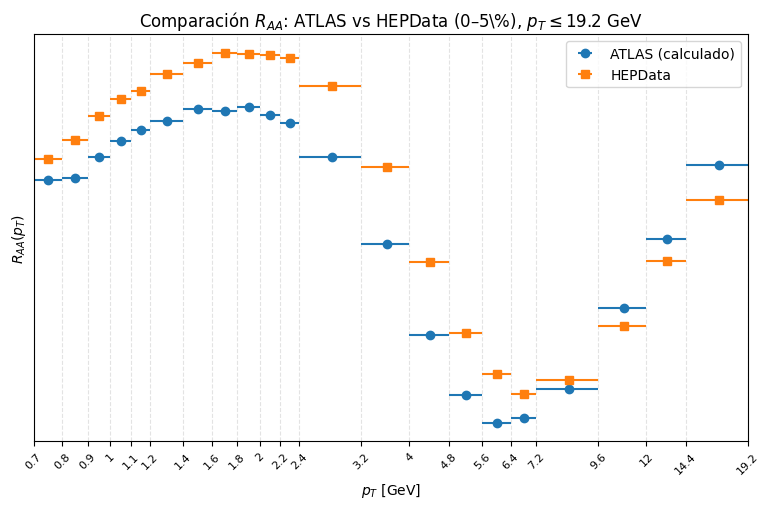

In [18]:
# =========================
# COMPARACIÓN R_AA: (ATLAS calculado desde parquets) vs HEPData + GRÁFICO SUPERPUESTO
# + agrega columna de CUENTAS (ATLAS) y fila final: TOTAL CUENTAS
# + mantiene PT mostrado con 2 decimales
# + RECORTE hasta 19.2 GeV
# =========================

PT_MAX = 19.2

# -------------------------
# 0) Centralidad y factores
# -------------------------
CENT_LO, CENT_HI = 0, 5
FACTOR_INV = 10
SIGMA_PP_INEL = 70.0  # [mb]

TAA_por_centralidad = {
    (0.0, 5.0): 26.23,
    (5.0, 10.0): 20.47,
    (10.0, 30.0): 11.7,
    (30.0, 50.0): 3.82,
    (50.0, 70.0): 0.934,
    (70.0, 100.0): 0.152,
}

clave_cent = (float(CENT_LO), float(CENT_HI))
if clave_cent not in TAA_por_centralidad:
    raise ValueError(
        f"No tengo TAA mapeado para {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(TAA_por_centralidad.keys())}"
    )

TAA = float(TAA_por_centralidad[clave_cent])
print(f"TAA asignado automáticamente para {CENT_LO}-{CENT_HI}%: {TAA} mb^-1")

# -------------------------
# 1) Bins pT
# -------------------------
pt_intervalos = np.array(
    [0.7,0.8,0.9,1.0,1.1,1.2,1.4,1.6,1.8,2.0,2.2,2.4,3.2,4.0,4.8,5.6,6.4,7.2,9.6,12.0,14.4,19.2,
     24.0,28.8,35.2,41.6,48.0,60.8,73.6,86.4,103.6,120.8,140.0,165.0,250.0,400.0],
    dtype=float
)

pt_low  = pt_intervalos[:-1]
pt_high = pt_intervalos[1:]
Delta_pt = np.diff(pt_intervalos)
pt_centro_Bin = 0.5 * (pt_low + pt_high)

# -------------------------
# 2) PbPb desde parquets: eventos únicos + histograma pT
# -------------------------
N_ij = np.zeros(len(pt_intervalos) - 1, dtype=np.int64)
eventos_vistos = set()

for f in ArchivosIones:
    pf = pq.ParquetFile(f)

    for batch in pf.iter_batches(
        batch_size=500_000,
        columns=["runNumber", "eventNumber", "CentralityMin", "CentralityMax", "qOverP", "theta"]
    ):
        df = batch.to_pandas()

        centrality_prom = 0.5 * (df["CentralityMin"] + df["CentralityMax"])

        mask_evt = (
            np.isfinite(centrality_prom)
            & (centrality_prom >= CENT_LO)
            & (centrality_prom < CENT_HI)
        )

        eventos_batch = df.loc[mask_evt, ["runNumber", "eventNumber"]].drop_duplicates()
        for row in eventos_batch.itertuples(index=False):
            eventos_vistos.add((int(row.runNumber), int(row.eventNumber)))

        qOverP = df["qOverP"].to_numpy()
        theta  = df["theta"].to_numpy()

        p_mev = np.where(qOverP != 0, 1.0 / np.abs(qOverP), np.nan)
        pt_gev = (p_mev * np.sin(theta)) / 1000.0
        eta = -np.log(np.tan(theta / 2.0))

        mask_part = (
            mask_evt.to_numpy()
            & np.isfinite(qOverP)
            & np.isfinite(theta)
            & np.isfinite(pt_gev)
            & np.isfinite(eta)
            & (np.abs(eta) < 1.0)
        )

        pt_filtrado = pt_gev[mask_part]
        counts, _ = np.histogram(pt_filtrado, bins=pt_intervalos)
        N_ij += counts

        del df, centrality_prom, eventos_batch, qOverP, theta, p_mev, pt_gev, eta, pt_filtrado, counts
        gc.collect()

Nevt = len(eventos_vistos)
if Nevt == 0:
    raise ValueError("Nevt=0: no hay eventos en esa centralidad.")

# -------------------------
# 3) Espectro (1/Nevt) d^2N/(deta dpT), Δη=2
# -------------------------
Delta_eta = 2.0
Espectro = N_ij / (Nevt * Delta_eta * Delta_pt)
sigma_stat = np.sqrt(N_ij) / (Nevt * Delta_eta * Delta_pt)

# -------------------------
# 4) Rendimiento invariante PbPb
# -------------------------
InvYield = FACTOR_INV * Espectro / (2.0 * np.pi * pt_centro_Bin)
InvErr = FACTOR_INV * sigma_stat / (2.0 * np.pi * pt_centro_Bin)

# -------------------------
# 5) pp desde HEPData Table_7
# -------------------------
HEP_DIR_PP = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
archivo_pp = os.path.join(HEP_DIR_PP, "HEPData-Table_7-Espectro-pp.csv")

if not os.path.exists(archivo_pp):
    raise FileNotFoundError(
        f"No existe el archivo:\n{archivo_pp}\n"
        f"Revisa el nombre exacto con: !ls -lh {HEP_DIR_PP}"
    )

dfpp = pd.read_csv(archivo_pp, comment="#", sep=",", engine="python")

pt_pp = 0.5 * (
    dfpp.iloc[:, 1].astype(float).to_numpy()
    + dfpp.iloc[:, 2].astype(float).to_numpy()
)
y_pp_raw = dfpp.iloc[:, 3].astype(float).to_numpy()

yerr_pp_raw = None
if dfpp.shape[1] >= 5:
    try:
        yerr_pp_raw = dfpp.iloc[:, 4].astype(float).to_numpy()
    except Exception:
        yerr_pp_raw = None

y_pp = FACTOR_INV * y_pp_raw
yerr_pp = (FACTOR_INV * yerr_pp_raw) if yerr_pp_raw is not None else None

mask_ok = (pt_pp > 0) & np.isfinite(pt_pp) & (y_pp > 0) & np.isfinite(y_pp)
pt_ok, y_ok = pt_pp[mask_ok], y_pp[mask_ok]
logpt, logy = np.log(pt_ok), np.log(y_ok)

pt_eval = pt_centro_Bin
mask_range = (
    (pt_eval >= pt_ok.min())
    & (pt_eval <= pt_ok.max())
    & np.isfinite(pt_eval)
    & (pt_eval > 0)
)

inv_pp_interp = np.full_like(pt_eval, np.nan, dtype=float)
inv_pp_interp[mask_range] = np.exp(
    np.interp(np.log(pt_eval[mask_range]), logpt, logy)
)

if yerr_pp is not None:
    rel = np.where(y_ok > 0, (yerr_pp[mask_ok] / y_ok), np.nan)
    rel_interp = np.full_like(pt_eval, np.nan, dtype=float)
    rel_interp[mask_range] = np.interp(np.log(pt_eval[mask_range]), logpt, rel)
    inv_pp_interp_err = rel_interp * inv_pp_interp
else:
    inv_pp_interp_err = np.zeros_like(pt_eval, dtype=float)

# -------------------------
# 6) R_AA calculado + error
# -------------------------
denom = (TAA * SIGMA_PP_INEL) * inv_pp_interp
denom_err = (TAA * SIGMA_PP_INEL) * inv_pp_interp_err

RAA = InvYield / denom
RAA_err = np.abs(RAA) * np.sqrt(
    (InvErr / np.where(InvYield != 0, InvYield, np.nan))**2 +
    (denom_err / np.where(denom != 0, denom, np.nan))**2
)

mask = (
    (N_ij > 0)
    & np.isfinite(RAA)
    & np.isfinite(RAA_err)
    & np.isfinite(denom)
    & (denom > 0)
    & (InvYield > 0)
)

# -------------------------
# 7) Leer R_AA de HEPData (Table_8..13)
# -------------------------
HEP_DIR_RAA = "/home/brayan/SEMINARIO_INVESTIGACION/atlas_datos/RAA/Datos_HEP_CSV"
hep_archivos_por_centralidad = {
    (0, 5):   "HEPData-ins1496050-v2-Table_8.csv",
    (5, 10):  "HEPData-ins1496050-v2-Table_9.csv",
    (10, 30): "HEPData-ins1496050-v2-Table_10.csv",
    (30, 50): "HEPData-ins1496050-v2-Table_11.csv",
    (50, 70): "HEPData-ins1496050-v2-Table_12.csv",
    (70, 90): "HEPData-ins1496050-v2-Table_13.csv",
}

clave_cent_int = (int(CENT_LO), int(CENT_HI))
if clave_cent_int == (70, 100):
    clave_para_hep = (70, 90)
else:
    clave_para_hep = clave_cent_int

if clave_para_hep not in hep_archivos_por_centralidad:
    raise ValueError(
        f"No hay archivo HEPData RAA para centralidad {CENT_LO}-{CENT_HI}%. "
        f"Opciones: {sorted(hep_archivos_por_centralidad.keys())}"
    )

archivo_hep = os.path.join(HEP_DIR_RAA, hep_archivos_por_centralidad[clave_para_hep])
if not os.path.exists(archivo_hep):
    raise FileNotFoundError(
        f"No existe: {archivo_hep}\n"
        f"Tip: revisa nombres con: !ls -lh {HEP_DIR_RAA}"
    )

df_hep = pd.read_csv(archivo_hep, comment="#", sep=",", engine="python")
pt_low_hep  = df_hep.iloc[:, 1].astype(float).to_numpy()
pt_high_hep = df_hep.iloc[:, 2].astype(float).to_numpy()
pt_hep      = 0.5 * (pt_low_hep + pt_high_hep)
raa_hep     = df_hep.iloc[:, 3].astype(float).to_numpy()

tabla_hep = pd.DataFrame({
    "pT_low [GeV]": pt_low_hep,
    "pT_high [GeV]": pt_high_hep,
    "pT_center [GeV]": pt_hep,
    "HEP_RAA": raa_hep,
})

# -------------------------
# 8) Tabla ATLAS (desde tu cálculo) + CUENTAS
# -------------------------
tabla_atlas = pd.DataFrame({
    "pT_low [GeV]": pt_low[mask],
    "pT_high [GeV]": pt_high[mask],
    "pT_center [GeV]": pt_centro_Bin[mask],
    "ATLAS_RAA": RAA[mask],
    "counts": N_ij[mask],
})

for t in (tabla_atlas, tabla_hep):
    t["_low_key"]  = t["pT_low [GeV]"].map(lambda v: f"{float(v):.6f}")
    t["_high_key"] = t["pT_high [GeV]"].map(lambda v: f"{float(v):.6f}")

tabla_comp = pd.merge(
    tabla_atlas,
    tabla_hep[["_low_key", "_high_key", "HEP_RAA"]],
    on=["_low_key", "_high_key"],
    how="inner"
)

# recorte hasta 19.2 GeV usando el borde superior del bin
tabla_comp = tabla_comp[tabla_comp["pT_high [GeV]"] <= PT_MAX].copy()

tabla_comp["Porcentaje de error [%]"] = (
    np.abs(tabla_comp["ATLAS_RAA"] - tabla_comp["HEP_RAA"]) / tabla_comp["HEP_RAA"]
) * 100.0

tabla_comp = tabla_comp.drop(columns=["_low_key", "_high_key"]).rename(columns={
    "pT_low [GeV]": "PTlow [GeV]",
    "pT_high [GeV]": "PThigh [GeV]",
    "pT_center [GeV]": "PT [GeV]",
    "ATLAS_RAA": "RAA medido ATLAS",
    "HEP_RAA": "RAA medido HEP",
    "counts": "Cuentas (ATLAS)",
})

orden_cols = [
    "PTlow [GeV]",
    "PThigh [GeV]",
    "PT [GeV]",
    "RAA medido ATLAS",
    "RAA medido HEP",
    "Cuentas (ATLAS)",
    "Porcentaje de error [%]",
]
tabla_comp = tabla_comp[orden_cols]

# -------------------------
# 8.1) Fila final: Total cuentas
# -------------------------
total_cuentas = int(np.nansum(tabla_comp["Cuentas (ATLAS)"].to_numpy(dtype=float)))

fila_total = {
    "PTlow [GeV]": np.nan,
    "PThigh [GeV]": np.nan,
    "PT [GeV]": "Total cuentas",
    "RAA medido ATLAS": np.nan,
    "RAA medido HEP": np.nan,
    "Cuentas (ATLAS)": total_cuentas,
    "Porcentaje de error [%]": np.nan,
}
tabla_comp = pd.concat([tabla_comp, pd.DataFrame([fila_total])], ignore_index=True)

# -------------------------
# 8.2) Mostrar tabla profesional
# -------------------------
print(
    f"\nTabla: Comparación R_AA ATLAS vs HEPData para centralidad {CENT_LO}-{CENT_HI}% "
    f"(archivo: {os.path.basename(archivo_hep)}) con recorte pT<= {PT_MAX} GeV"
)

def fmt_num(dec):
    def _f(x):
        if x is None:
            return ""
        if isinstance(x, str):
            return x
        try:
            if np.isnan(x):
                return ""
        except Exception:
            pass
        return f"{float(x):.{dec}f}"
    return _f

def fmt_int(x):
    if x is None:
        return ""
    if isinstance(x, str):
        return x
    try:
        if np.isnan(x):
            return ""
    except Exception:
        pass
    return f"{int(round(float(x))):d}"

display(
    tabla_comp.style
    .format({
        "PTlow [GeV]": fmt_num(1),
        "PThigh [GeV]": fmt_num(1),
        "PT [GeV]": fmt_num(2),
        "RAA medido ATLAS": fmt_num(6),
        "RAA medido HEP": fmt_num(6),
        "Cuentas (ATLAS)": fmt_int,
        "Porcentaje de error [%]": fmt_num(3),
    })
    .hide(axis="index")
    .set_caption(
        f"Comparación de $R_{{AA}}$: ATLAS calculado desde parquets vs HEPData ({CENT_LO}-{CENT_HI}%), con recorte pT ≤ {PT_MAX} GeV"
    )
)

# -------------------------
# 9) Gráfico superpuesto ATLAS vs HEPData
# -------------------------
tabla_plot = tabla_comp.iloc[:-1].copy()

x      = tabla_plot["PT [GeV]"].to_numpy(dtype=float)
y_at   = tabla_plot["RAA medido ATLAS"].to_numpy(dtype=float)
y_hep2 = tabla_plot["RAA medido HEP"].to_numpy(dtype=float)

ptlow_plot  = tabla_plot["PTlow [GeV]"].to_numpy(dtype=float)
pthigh_plot = tabla_plot["PThigh [GeV]"].to_numpy(dtype=float)
xerr_plot   = np.vstack([x - ptlow_plot, pthigh_plot - x])

mplot = (
    np.isfinite(x)
    & np.isfinite(y_at)
    & np.isfinite(y_hep2)
    & (x > 0)
    & (y_at > 0)
    & (y_hep2 > 0)
)

fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.errorbar(
    x[mplot], y_at[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="o", linestyle="none", capsize=0, label="ATLAS (calculado)"
)
ax.errorbar(
    x[mplot], y_hep2[mplot],
    xerr=xerr_plot[:, mplot],
    fmt="s", linestyle="none", capsize=0, label="HEPData"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel(r"$R_{AA}(p_T)$")
ax.set_title(rf"Comparación $R_{{AA}}$: ATLAS vs HEPData ({CENT_LO}–{CENT_HI}\%), $p_T \leq {PT_MAX}$ GeV")
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()

ticks = pt_intervalos[pt_intervalos <= PT_MAX]
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.xaxis.set_major_formatter(FixedFormatter([f"{v:g}" for v in ticks]))
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.minorticks_off()
ax.set_xlim(float(np.min(ticks)), PT_MAX)

plt.tight_layout()
plt.show()